# Fitness Trends Analysis (Google Trends)
The goal of this project is to analyze search interest data related to general workouts (`workout`) and specific keywords (`home workout`, `gym workout`, `home gym`) over time and across different countries.
We will clean the data, build a Data Model to link the time-series and geographical data, and extract key analytical insights.

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

plt.figure(figsize=(14, 7))

if 'month_name' not in df_time_model.columns:
    df_time_model['year'] = df_time_model['month'].dt.year
    df_time_model['month_name'] = df_time_model['month'].dt.month.apply(lambda x: calendar.month_abbr[x])



<Figure size 1400x700 with 0 Axes>

## 1. Data Loading
We will read the four CSV files containing the time-series data and geographical data.

In [2]:
# Read Time Series files
df_workout = pd.read_csv('workout.csv')
df_keywords = pd.read_csv('three_keywords.csv')

# Read Geographical Data files
df_workout_geo = pd.read_csv('workout_geo.csv')
df_keywords_geo = pd.read_csv('three_keywords_geo.csv')

print("Data loaded successfully!")

Data loaded successfully!


## 2. Data Cleaning
* Convert date columns to `datetime` format to facilitate time-series analysis.
* Standardize column names (e.g., changing `country` to `Country`) to make merging easier.
* Handle missing values (NaN). In the context of Google Trends, a NaN value usually means the search volume was less than 1%, so we will replace them with zeros.

In [10]:
# 1. Clean Time Series Data
# Convert 'month' column to datetime objects
df_workout['month'] = pd.to_datetime(df_workout['month'])
df_keywords['month'] = pd.to_datetime(df_keywords['month'])

# 2. Clean Geographical Data
# Standardize the country column name to 'Country' in both dataframes
df_workout_geo.rename(columns={'country': 'Country'}, inplace=True)

# Replace missing values (NaN) with zero (0)
df_workout_geo.fillna(0, inplace=True)
df_keywords_geo.fillna(0, inplace=True)

# Convert geographical data columns to numeric types after filling NaNs
for col in df_workout_geo.columns[1:]:
    df_workout_geo[col] = pd.to_numeric(df_workout_geo[col], errors='coerce').fillna(0)

for col in df_keywords_geo.columns[1:]:
    df_keywords_geo[col] = pd.to_numeric(df_keywords_geo[col], errors='coerce').fillna(0)

print("Data cleaned successfully!")

Data cleaned successfully!


## 3. Data Modeling
We will segment the data into two main Fact Tables:
1. **Time_Data_Model**: Merges the general `workout` data with the three keywords based on the `month` column.
2. **Geo_Data_Model**: Merges the general `workout` interest with the keywords based on the `Country` column.

In [4]:
# Time-based merge (Inner Join on 'month')
df_time_model = pd.merge(df_workout, df_keywords, on='month', how='inner')

# Geographical merge (Inner Join on 'Country')
df_geo_model = pd.merge(df_workout_geo, df_keywords_geo, on='Country', how='inner')

display(df_time_model.head())
display(df_geo_model.head())

,month,workout_worldwide,home_workout_worldwide,gym_workout_worldwide,home_gym_worldwide
0,2018-03-01,59,12,16,10
1,2018-04-01,61,12,18,10
2,2018-05-01,57,13,16,9
3,2018-06-01,56,12,17,9
4,2018-07-01,51,12,17,9


,Country,workout_2018_2023,home_workout_2018_2023,gym_workout_2018_2023,home_gym_2018_2023
0,Guam,0.0,0.0,0.0,0.0
1,Falkland Islands (Islas Malvinas),0.0,0.0,0.0,0.0
2,Cook Islands,0.0,0.0,0.0,0.0
3,Brunei,0.0,0.0,0.0,0.0
4,Palau,0.0,0.0,0.0,0.0


## 4. Data Analysis & Visualization
### A. Time Series Analysis
We will compare the interest in home workouts versus gym workouts over time to discover patterns (such as the impact of the COVID-19 pandemic in early 2020).

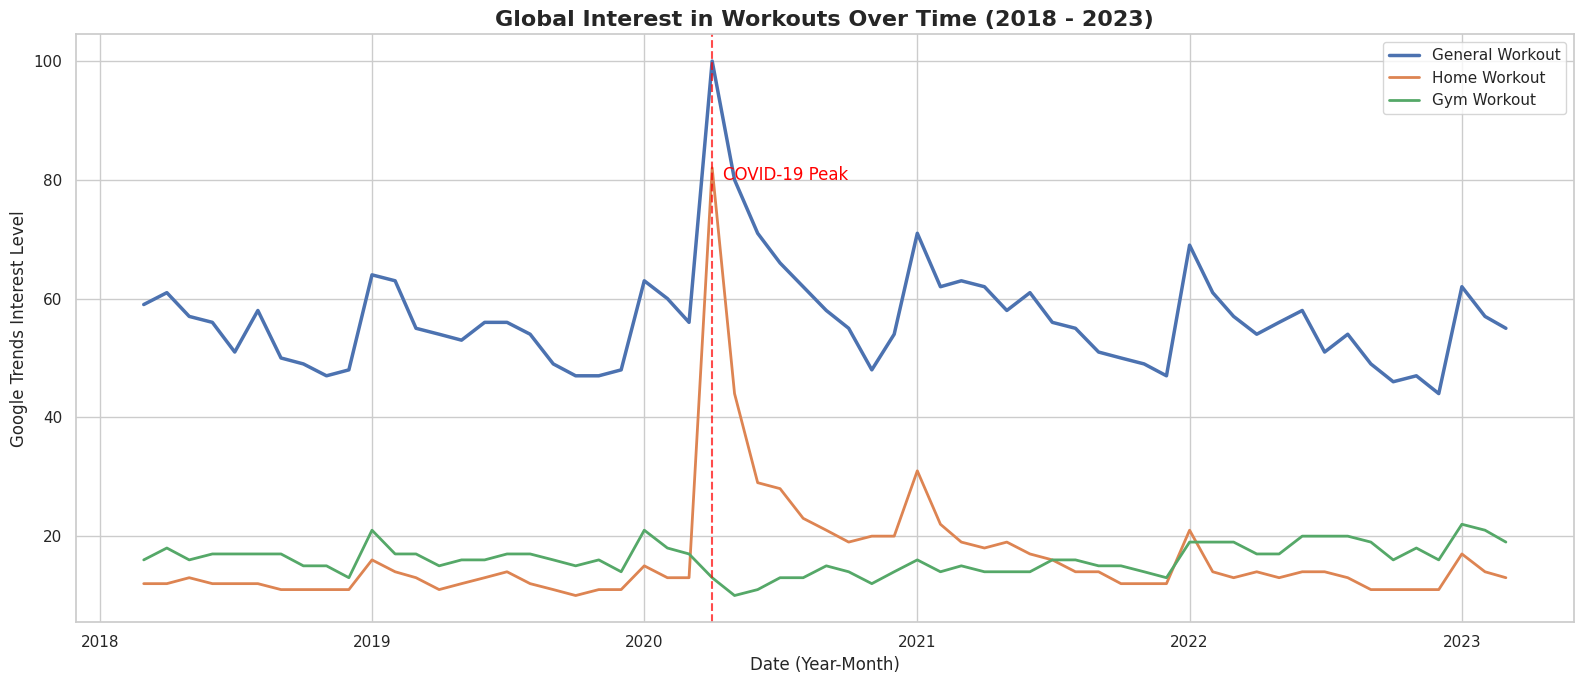

In [5]:
plt.figure(figsize=(16, 7))

# Plot time series lines
sns.lineplot(data=df_time_model, x='month', y='workout_worldwide', label='General Workout', linewidth=2.5)
sns.lineplot(data=df_time_model, x='month', y='home_workout_worldwide', label='Home Workout', linewidth=2)
sns.lineplot(data=df_time_model, x='month', y='gym_workout_worldwide', label='Gym Workout', linewidth=2)

# Add title and axis labels
plt.title('Global Interest in Workouts Over Time (2018 - 2023)', fontsize=16, fontweight='bold')
plt.xlabel('Date (Year-Month)', fontsize=12)
plt.ylabel('Google Trends Interest Level', fontsize=12)

# Highlight the COVID-19 period (April 2020)
plt.axvline(pd.to_datetime('2020-04-01'), color='red', linestyle='--', alpha=0.7)
plt.text(pd.to_datetime('2020-04-15'), 80, 'COVID-19 Peak', color='red', fontsize=12)

plt.legend()
plt.tight_layout()
plt.show()

### B. Geographical Analysis
We will analyze the top 10 countries with the highest overall interest in workouts, and break down their interest in specific workout types.

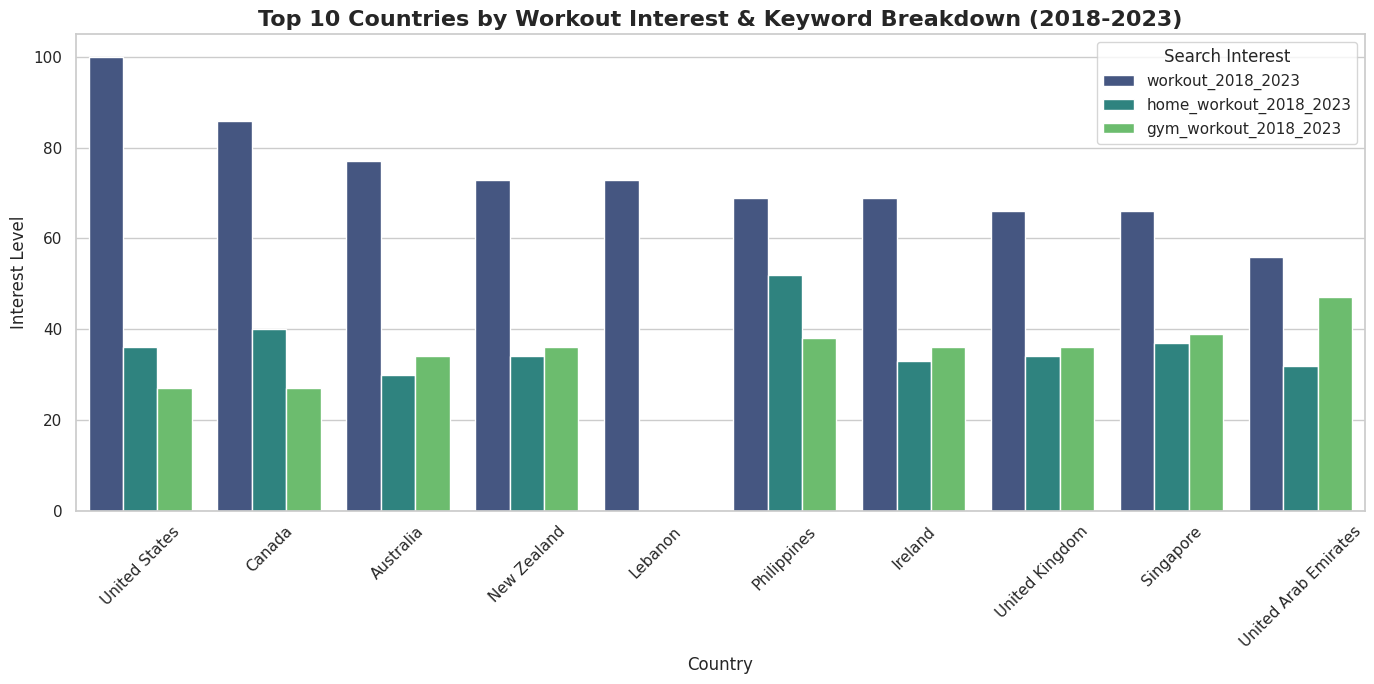

In [6]:
# Sort countries by general workout interest to get the top 10
top_10_countries = df_geo_model.sort_values(by='workout_2018_2023', ascending=False).head(10)

# Reshape data for plotting (Melt for Seaborn Barplot)
top_10_melted = top_10_countries.melt(
    id_vars=['Country'],
    value_vars=['workout_2018_2023', 'home_workout_2018_2023', 'gym_workout_2018_2023'],
    var_name='Category',
    value_name='Interest Level'
)

# Plotting
plt.figure(figsize=(14, 7))
sns.barplot(data=top_10_melted, x='Country', y='Interest Level', hue='Category', palette='viridis')

plt.title('Top 10 Countries by Workout Interest & Keyword Breakdown (2018-2023)', fontsize=16, fontweight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Interest Level', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Search Interest')
plt.tight_layout()
plt.show()


### F. Global Distribution of Workout Interest
This density plot shows how workout interest is distributed across all countries. It helps us understand if high interest is common globally or restricted to just a few countries.

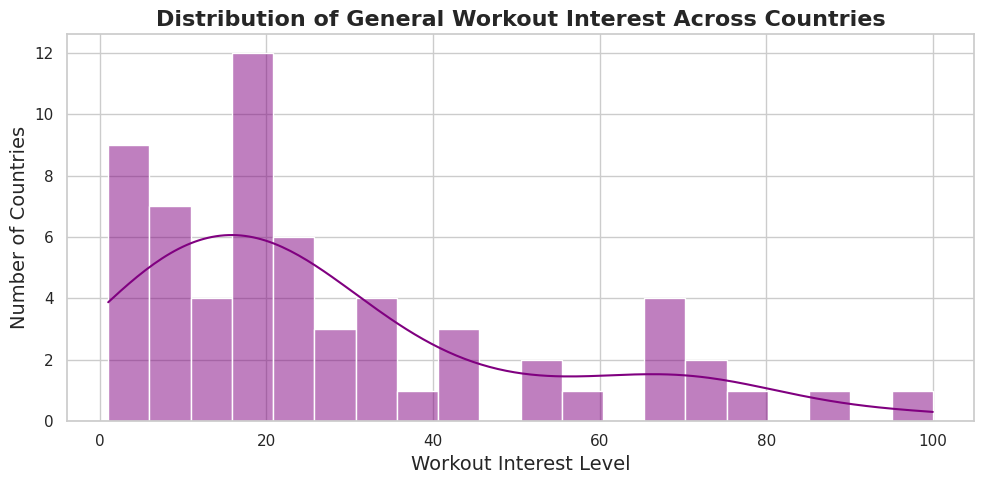

In [7]:
plt.figure(figsize=(10, 5))

# Filter out countries with 0 interest for a cleaner distribution
active_countries = df_geo_model[df_geo_model['workout_2018_2023'] > 0]

sns.histplot(active_countries['workout_2018_2023'], bins=20, kde=True, color='purple')

plt.title('Distribution of General Workout Interest Across Countries', fontsize=16, fontweight='bold')
plt.xlabel('Workout Interest Level', fontsize=14)
plt.ylabel('Number of Countries', fontsize=14)
plt.tight_layout()
plt.show()

### Heatmap of Top 20 Countries Across All Categories
A color-coded matrix showing the intensity of search interest for all keywords simultaneously in the top 20 countries.

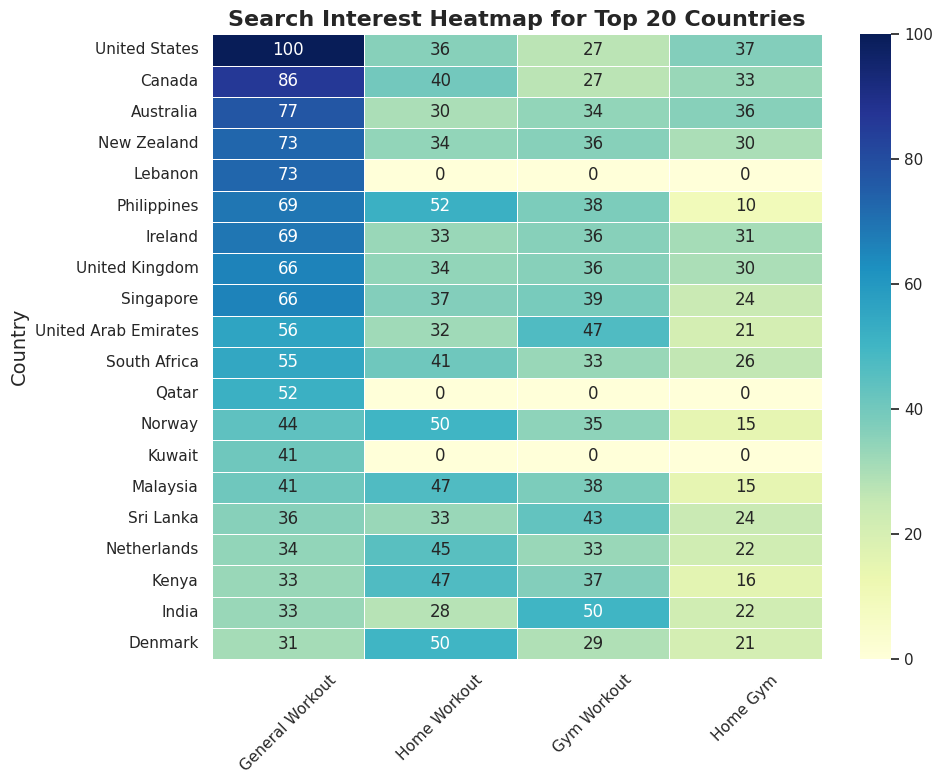

In [8]:
# 3. Heatmap of Top 20 Countries
plt.figure(figsize=(10, 8))

# Sort by total workout interest and set index to Country
top_20_geo = df_geo_model.sort_values(by='workout_2018_2023', ascending=False).head(20)
top_20_geo_indexed = top_20_geo.set_index('Country')

# Select only the keyword columns for the heatmap
heatmap_data = top_20_geo_indexed[['workout_2018_2023', 'home_workout_2018_2023',
                                   'gym_workout_2018_2023', 'home_gym_2018_2023']]

# Rename columns for cleaner display
heatmap_data.columns = ['General Workout', 'Home Workout', 'Gym Workout', 'Home Gym']

sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt=".0f", linewidths=.5)

plt.title('Search Interest Heatmap for Top 20 Countries', fontsize=16, fontweight='bold')
plt.ylabel('Country', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Year-over-Year (YoY) General Workout Trends
Comparing the shape of the search interest curve across different years. This perfectly isolates the 2020 COVID-19 anomaly from normal years.

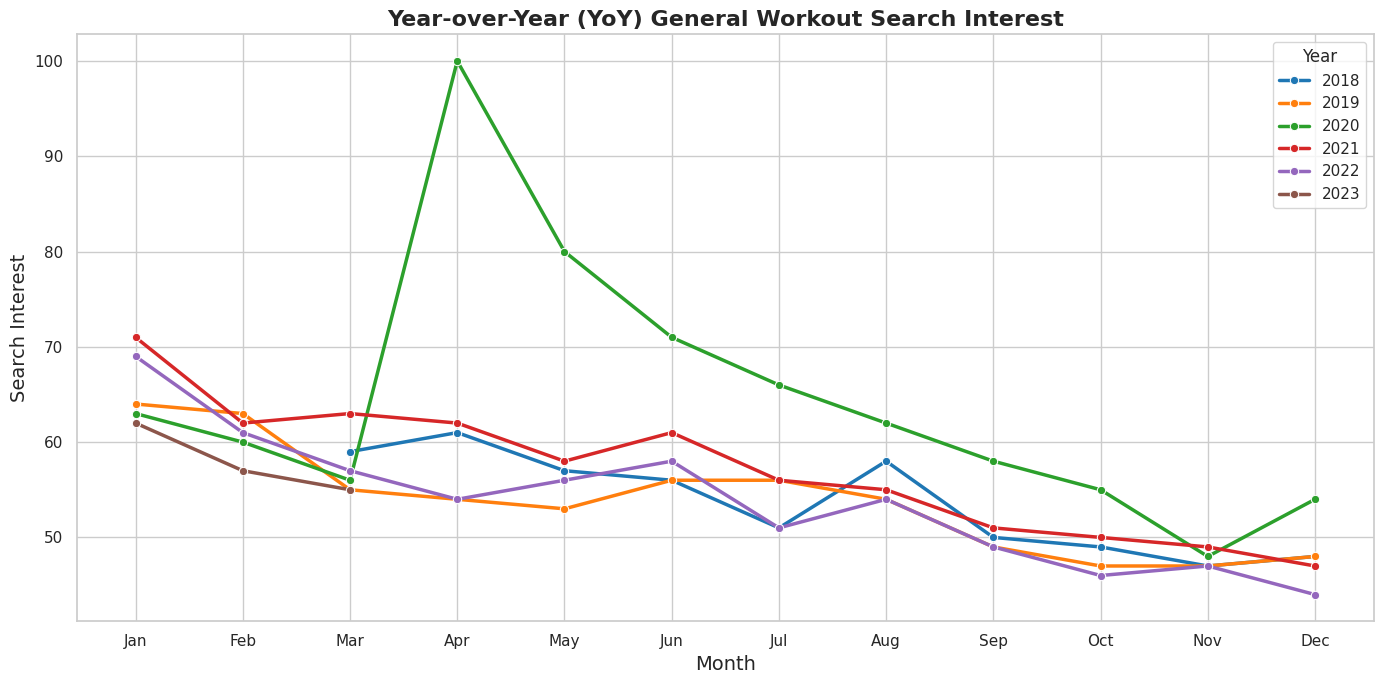

In [15]:
# 4. Year-over-Year (YoY) comparison
plt.figure(figsize=(14, 7))

# Create a pivot table: Rows = Month Name, Columns = Year, Values = Workout Worldwide
# Ensure 'month_name' exists (from previous cleaning step)
if 'month_name' not in df_time_model.columns:
    df_time_model['year'] = df_time_model['month'].dt.year
    df_time_model['month_name'] = df_time_model['month'].dt.month.apply(lambda x: calendar.month_abbr[x])

yoy_data = df_time_model.pivot(index='month_name', columns='year', values='workout_worldwide')

# Reorder index to follow logical month order rather than alphabetical
month_order = [calendar.month_abbr[i] for i in range(1, 13)]
yoy_data = yoy_data.reindex(month_order)

# Plot each year
sns.lineplot(data=yoy_data, dashes=False, palette='tab10', linewidth=2.5, marker='o')

plt.title('Year-over-Year (YoY) General Workout Search Interest', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=14)
plt.ylabel('Search Interest', fontsize=14)
plt.legend(title='Year', loc='upper right')
plt.tight_layout()
plt.show()

## 4. Final Executive Summary & Insights
1. **The Pandemic Shock:** The time series clearly illustrates the "COVID-19 shock" where `home workout` spiked tremendously in April 2020 while `gym workout` dropped. Over time, the trend inverted as gyms reopened.
2. **New Year, New Me:** The Seasonality Boxplot shows that **January** generally has the highest median search interest for workouts, validating the "New Year's Resolution" trend in fitness.
3. **Keyword Correlation:** The Heatmap shows a strong positive correlation between `workout_worldwide` and `home_workout_worldwide`, indicating that during peak global fitness periods, home routines drive a massive part of the traffic.
4. **Geographical Leaders:** Western and English-speaking countries (USA, Canada, Australia, UK, Ireland, New Zealand) heavily dominate general fitness searches.
5. **Workout Preferences:** While the US and Canada have strong interest in home workouts, countries like India show a disproportionately massive preference for `gym workout` compared to `home workout`.
6. **Global Distribution:** The distribution plot is right-skewed, meaning that while most countries have low-to-medium search interest (0-30 range), a select few highly engaged countries push the upper bounds (70-100 range).